The purpose of this notebook is to compute the power spectrum of the Mitchell et al. (2011) data. I want to figure out if detrending the data is a good idea, and I want to see how well a simple AR(1) model fits the data.

In [2]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy.signal import lombscargle
from scipy.ndimage import gaussian_filter1d
from multitaper import mtspec

from methane_noise_forcing import compute_ar1_params_from_tau, generate_ar1_noise

# import data and format

In [3]:
path_methane = "/Users/ericm/Documents/Research/intro_and_motivation_figs/data/ch4/past_2000/WDC05A_mitchell2011.csv"

age_col = 'Gas Age (Year C.E., timescale:"WDC05A:2")'
df = pd.read_csv(
    path_methane, usecols=["Mean depth (m)", age_col, "Mean Concentration (ppb)"]
).rename(columns={age_col: "Gas_Age_CE"})

df["Gas_Age_CE"] = df["Gas_Age_CE"].astype(float)

df.head()

,Mean depth (m),Gas_Age_CE,Mean Concentration (ppb)
0,109.215,1814.20,739.273119
1,110.490,1808.78,742.922299
2,110.880,1807.67,737.708567
3,112.930,1799.91,735.613533
4,113.160,1798.93,731.514054


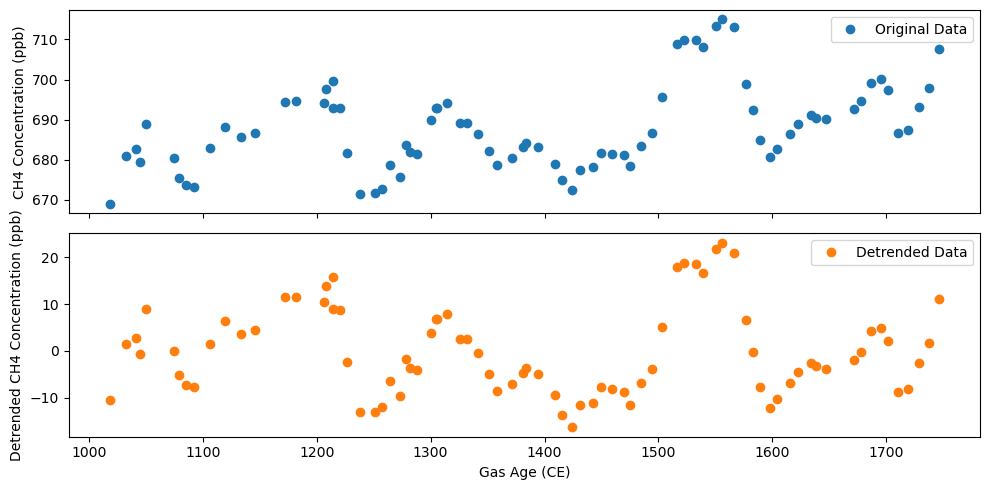

In [4]:
# filter data: max gas age is 1750 CE
df_filtered = df[df["Gas_Age_CE"] <= 1750].copy()
mitchell_time = df_filtered["Gas_Age_CE"].values
mitchell_ch4 = df_filtered["Mean Concentration (ppb)"].values

# detrend data
coeffs = np.polyfit(mitchell_time, mitchell_ch4, 1)
mitchell_ch4_detrended = mitchell_ch4 - np.polyval(coeffs, mitchell_time)

# plot data
fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axs[0].plot(mitchell_time, mitchell_ch4, "o", label="Original Data")
axs[0].set_ylabel("CH4 Concentration (ppb)")
axs[0].legend()
axs[1].plot(
    mitchell_time,
    mitchell_ch4_detrended,
    "o",
    label="Detrended Data",
    color="tab:orange",
)
axs[1].set_xlabel("Gas Age (CE)")
axs[1].set_ylabel("Detrended CH4 Concentration (ppb)")
axs[1].legend()
plt.tight_layout()

# Power spectrum
Using Lomb-Scargle for methane

In [5]:
# Calculate Lomb-Scargle power spectrum
# First, define frequency range
dt_mean = np.abs(np.mean(np.diff(mitchell_time)))
nyquist = 1 / (2 * dt_mean)  # Nyquist frequency
freq_min = 1 / (mitchell_time.max() - mitchell_time.min()) * 2  # lowest frequency
# freq_min = 1 / 200
N = len(mitchell_time)
frequencies = np.linspace(freq_min, nyquist, 4 * N)

# Convert to angular frequencies for lombscargle
angular_frequencies = 2 * np.pi * frequencies

# Calculate power spectrum for original data
mitchell_ch4_demean = mitchell_ch4 - np.mean(mitchell_ch4)
power_original = lombscargle(
    mitchell_time, mitchell_ch4_demean, angular_frequencies, normalize=False
)

# Calculate power spectrum for detrended data
power_detrended = lombscargle(
    mitchell_time, mitchell_ch4_detrended, angular_frequencies, normalize=False
)

In [6]:
# Smooth the power spectra with Gaussian kernel
sigma_idx = 6  # smoothing parameter (measured in array indices)
power_original_smooth = gaussian_filter1d(power_original, sigma_idx)
power_detrended_smooth = gaussian_filter1d(power_detrended, sigma_idx)

# Calculate correct degrees of freedom for Gaussian smoothing
# For central points, DoF is approximately 4√π × σ
nu_center = 4 * np.sqrt(np.pi) * sigma_idx


# Function to calculate DoF profile that accounts for edge truncation
def dof_profile(n_bins, sigma_idx, n_trunc=9):
    """Calculate DoF for each bin considering edge truncation."""
    # Create full Gaussian window with truncation at n_trunc*sigma
    k = np.arange(-n_trunc * sigma_idx, n_trunc * sigma_idx + 1)
    w_full = np.exp(-0.5 * (k / sigma_idx) ** 2)

    # Calculate DoF for each bin
    out = np.empty(n_bins)
    for i in range(n_bins):
        # Shift & truncate window where it runs out of data
        lo = max(0, i - n_trunc * sigma_idx)
        hi = min(n_bins, i + n_trunc * sigma_idx + 1)
        w = w_full[(lo - i) + n_trunc * sigma_idx : (hi - i) + n_trunc * sigma_idx]
        w = w / w.sum()  # Normalize weights
        out[i] = 2 / np.sum(w**2)  # DoF = 2 / sum(w²)
    return out


# Calculate DoF for each frequency bin
nu = dof_profile(len(frequencies), sigma_idx)

# Print results for central points (away from edges)
print(f"Number of data points: {N}")
print(f"Gaussian sigma: {sigma_idx}")
print(f"Min DoF (at edges): {np.min(nu):.1f}")
print(f"Max DoF (central): {np.max(nu):.1f}")

# Calculate confidence intervals for chi-square distribution
alpha = 0.05  # 95% confidence interval
lower_factor = scipy.stats.chi2.ppf(1 - alpha / 2, nu_center) / nu_center
upper_factor = scipy.stats.chi2.ppf(alpha / 2, nu_center) / nu_center

print(f"\n95% confidence interval factors (for central points):")
print(f"Lower: {1/upper_factor:.3f} (multiply by this factor)")
print(f"Upper: {1/lower_factor:.3f} (multiply by this factor)")

# If you want to add confidence intervals to your plot
# Use nu instead of a single dof value for position-dependent intervals
lower_bound = power_original_smooth / upper_factor  # For central points
upper_bound = power_original_smooth / lower_factor  # For central points

# For full position-dependent bounds:
# lower_bound = np.array([power_original_smooth[i] / (scipy.stats.chi2.ppf(1-alpha/2, nu[i])/nu[i]) for i in range(len(nu))])
# upper_bound = np.array([power_original_smooth[i] / (scipy.stats.chi2.ppf(alpha/2, nu[i])/nu[i]) for i in range(len(nu))])

Number of data points: 81
Gaussian sigma: 6
Min DoF (at edges): 22.1
Max DoF (central): 42.5

95% confidence interval factors (for central points):
Lower: 1.610 (multiply by this factor)
Upper: 0.681 (multiply by this factor)


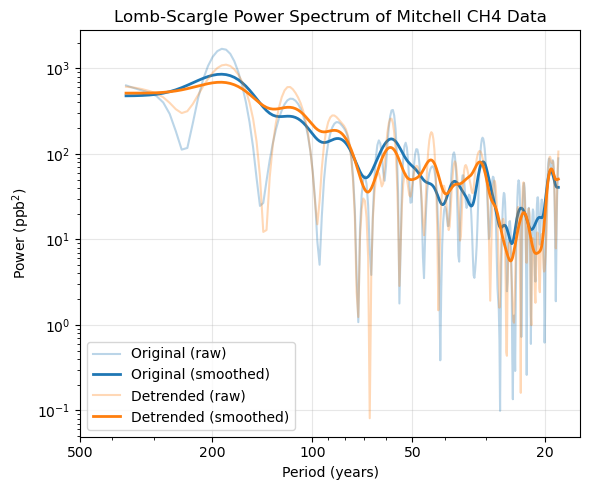


Period range: 18.2 to 363.6 years


In [7]:
# Plot results
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# Define custom tick locations and labels
tick_periods = [500, 200, 100, 50, 20]

# Plot power spectra
ax.loglog(
    1 / frequencies, power_original, alpha=0.3, label="Original (raw)", color="tab:blue"
)
ax.loglog(
    1 / frequencies,
    power_original_smooth,
    label="Original (smoothed)",
    color="tab:blue",
    linewidth=2,
)
ax.loglog(
    1 / frequencies,
    power_detrended,
    alpha=0.3,
    label="Detrended (raw)",
    color="tab:orange",
)
ax.loglog(
    1 / frequencies,
    power_detrended_smooth,
    label="Detrended (smoothed)",
    color="tab:orange",
    linewidth=2,
)
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$)")
ax.set_title("Lomb-Scargle Power Spectrum of Mitchell CH4 Data")
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # Invert x-axis so period decreases to the right
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)

plt.tight_layout()
plt.show()

# Convert to periods for easier interpretation
periods = 1 / frequencies
print(f"\nPeriod range: {periods.min():.1f} to {periods.max():.1f} years")

I didn't realize how little data was actually in the mitchell high-resolution dataset. Detrending doesn't do a whole lot, but smoothing gets rid of much of the noise along with add DoF to the spectrum.

# Build simple AR(1) modesl forced by white noise
I'd like to see how well AR(1) models of methane could explain the data. I will generate AR(1) datasets with 8, 10, and 12 year lifetimes targetting the variance of the detrended data.

From testing, a time step of at most 1/48 years is recommended. None of the AR(1) models driven by white noise with reasonable methane decay timescales match the total spectral power in the observations. I'm not exactly sure why, other than a general misfit of the model to the observations.

In [85]:
def generate_ar1_with_spectrum(
    phi, sigma_eps, n_steps, frequencies, angular_frequencies, sigma_idx, rng
):
    """
    Generate AR(1) noise and compute its power spectrum.

    Parameters:
    -----------
    phi : float
        AR(1) coefficient
    sigma_eps : float
        Standard deviation of white noise
    n_steps : int
        Number of time steps
    frequencies : array
        Frequency array for power spectrum
    angular_frequencies : array
        Angular frequency array for Lomb-Scargle
    sigma_idx : int
        Smoothing parameter for Gaussian filter
    rng : numpy random generator
        Random number generator

    Returns:
    --------
    noise : array
        Generated AR(1) time series
    power : array
        Raw power spectrum
    power_smooth : array
        Smoothed power spectrum
    """
    # Generate AR(1) noise
    noise = generate_ar1_noise(phi=phi, sigma_eps=sigma_eps, n_steps=n_steps, rng=rng)

    # Calculate power spectrum using the same frequency range as before
    power = lombscargle(
        np.arange(0, n_years, dt_years),
        noise - np.mean(noise),
        angular_frequencies,
        normalize=False,
    )

    # Smooth the power spectrum
    power_smooth = gaussian_filter1d(power, sigma_idx)

    return noise, power, power_smooth

In [90]:
tau_arr = np.array([5, 8, 10, 12, 30])  # e-folding timescales in years
n_years = 1000  # number of years to simulate
n_ens = 10  # number of ensemble members
dt_years = 1 / 96  # time step
var_detrended = np.var(mitchell_ch4_detrended, ddof=1)

# generate random seeds
ss = np.random.SeedSequence(12345)
child_seqs = ss.spawn(n_ens)

noise_mapper = {}
psd_mapper = {}
psd_smooth_mapper = {}

for tau in tau_arr:
    # rows are ensemble members, columns are time steps
    noise_arr = np.empty((n_ens, int(n_years // dt_years)))
    psd_arr = np.empty((n_ens, len(frequencies)))
    psd_smooth_arr = np.empty((n_ens, len(frequencies)))

    # calculate AR(1) parameters from tau
    phi, sigma_cont, sigma_eps = compute_ar1_params_from_tau(
        tau_days=tau * 365, dt_days=dt_years * 365, variance=var_detrended
    )

    # loop over ensemble members
    for idx_ens in range(n_ens):
        # calculate noise and its power spectrum
        noise, power, power_smooth = generate_ar1_with_spectrum(
            phi,
            sigma_eps,
            int(n_years // dt_years),
            frequencies,
            angular_frequencies,
            sigma_idx,
            np.random.default_rng(child_seqs[idx_ens]),
        )
        # store results
        noise_arr[idx_ens, :] = noise
        psd_arr[idx_ens, :] = power
        psd_smooth_arr[idx_ens, :] = power_smooth

    # store in mapper
    noise_mapper[tau] = noise_arr
    psd_mapper[tau] = psd_arr
    psd_smooth_mapper[tau] = psd_smooth_arr

In [104]:
# calculate characteristics of the AR(1) fits:
from collections import namedtuple

# Define a simple container for results
FitResult = namedtuple(
    "FitResult",
    ["tau", "period", "psd_smooth", "slope", "se_slope", "intercept", "x_fit", "y_fit"],
)

results = []

for tau in tau_arr:
    # 1) average across ensemble members
    psd = psd_smooth_mapper[tau]  # shape (n_ensembles, n_freq)
    psd_smooth = psd.mean(axis=0)  # now shape (n_freq,)

    # 2) build mask for the period range of interest
    period = 1 / frequencies
    mask = (period >= 18) & (period <= 50)

    if not np.any(mask):
        print(f"Warning: no data in 18–50 yr band for τ={tau}")
        continue

    # 3) linear regression in log-log space
    x = np.log(period[mask])
    y = np.log(psd_smooth[mask])

    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    resid = y - y_pred
    mse = np.sum(resid**2) / (len(x) - 2)
    se_slope = np.sqrt(mse / np.sum((x - x.mean()) ** 2))

    # 4) build fit curve
    x_fit = np.linspace(period[mask].max(), period[mask].min(), 100)
    y_fit = np.exp(intercept) * x_fit**slope

    # 5) store everything
    results.append(
        FitResult(
            tau=tau,
            period=period,
            psd_smooth=psd_smooth,
            slope=slope,
            se_slope=se_slope,
            intercept=intercept,
            x_fit=x_fit,
            y_fit=y_fit,
        )
    )

# Now `results` is a list of FitResult; you can inspect or test it independently.

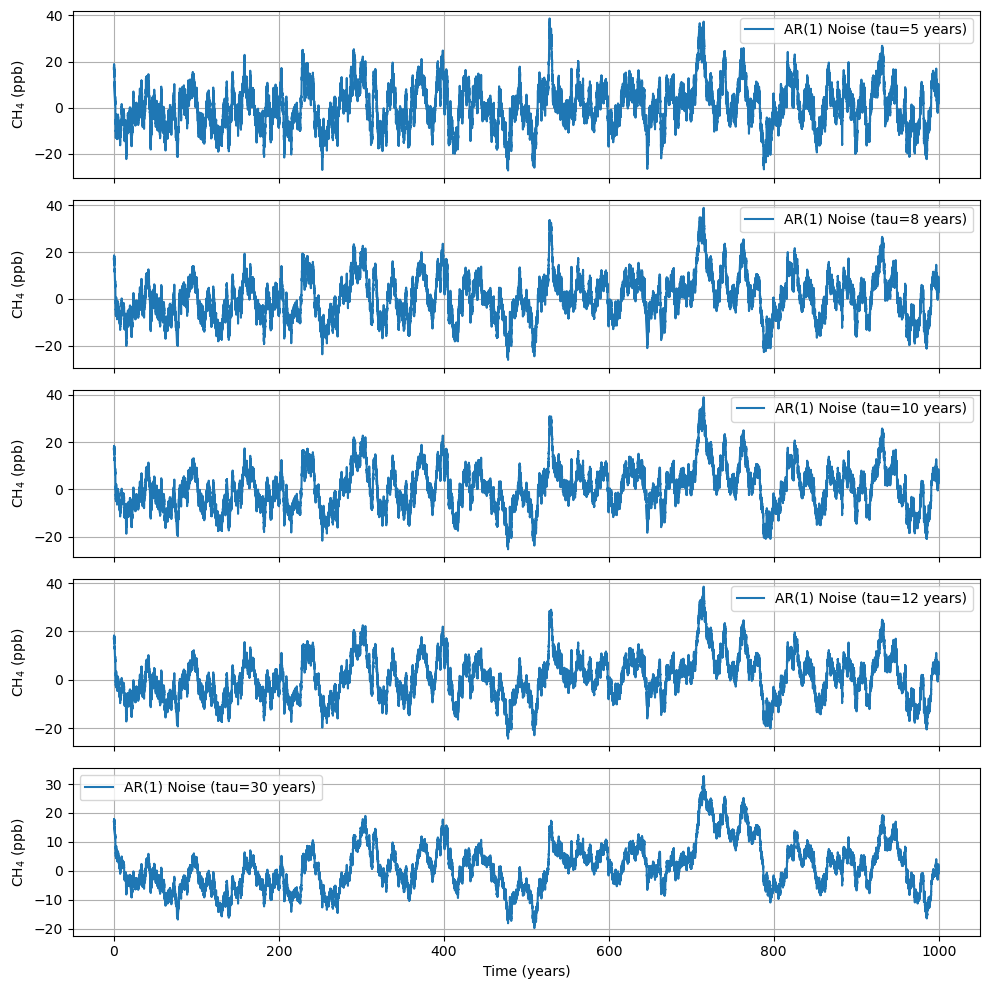

In [92]:
# Plot timeseries of first ensemble member for each tau
fig, axs = plt.subplots(len(tau_arr), 1, figsize=(10, 2 * len(tau_arr)), sharex=True)
for idx, tau in enumerate(tau_arr):
    noise = noise_mapper[tau][0]  # first ensemble member
    time_steps = np.arange(0, n_years, dt_years)

    axs[idx].plot(
        time_steps, noise, label=f"AR(1) Noise (tau={tau} years)", color="tab:blue"
    )
    axs[idx].set_ylabel("CH$_4$ (ppb)")
    axs[idx].legend()
    axs[idx].grid(True)
axs[-1].set_xlabel("Time (years)")
plt.tight_layout()

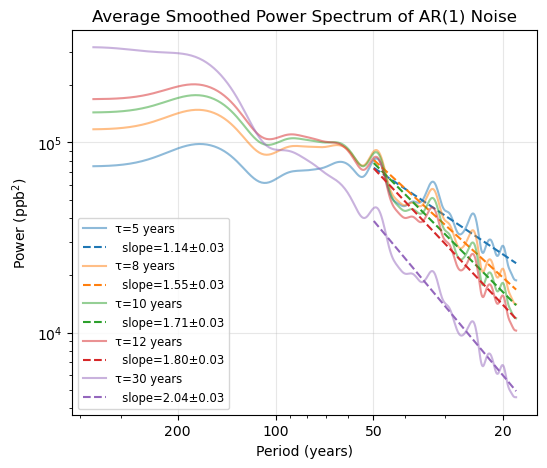

In [108]:
fig, ax = plt.subplots(figsize=(6, 5))

for res in results:
    # Plot the smoothed PSD
    ax.loglog(res.period, res.psd_smooth, alpha=0.5, label=f"τ={res.tau} years")

    # Grab the color that Matplotlib just used
    color = ax.get_lines()[-1].get_color()

    # Plot the fit line
    ax.plot(
        res.x_fit,
        res.y_fit,
        linestyle="--",
        color=color,
        label=f"  slope={res.slope:.2f}±{res.se_slope:.2f}",
    )

# Labels, grid, legend
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$)")
ax.set_title("Average Smoothed Power Spectrum of AR(1) Noise")

# Custom ticks (guard against out-of-range)
tick_periods = [p for p in [500, 200, 100, 50, 20] if p <= res.period.max()]
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)
ax.invert_xaxis()
ax.grid(alpha=0.3)
# Combine the labels neatly
ax.legend(loc="best", fontsize="small")

# Compare AR(1) spectrum to observations 

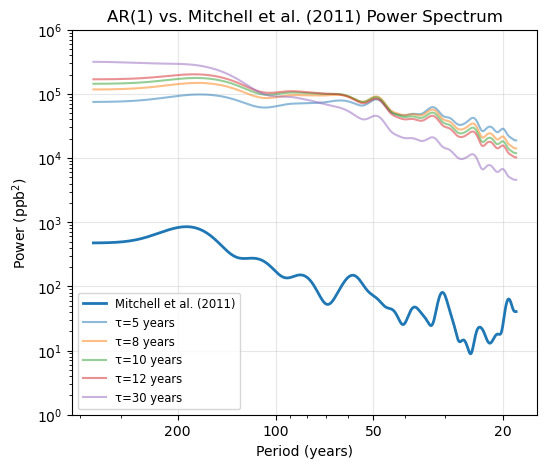

In [ ]:
# plot smoothed power spectrum of original data against AR(1) fits
fig, ax = plt.subplots(figsize=(6, 5))

ax.loglog(
    1 / frequencies,
    power_original_smooth,
    label="Mitchell et al. (2011)",
    color="tab:blue",
    linewidth=2,
)

for res in results:
    # Plot the smoothed PSD
    ax.loglog(res.period, res.psd_smooth, alpha=0.5, label=f"τ={res.tau} years")

# Labels, grid, legend
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$)")
ax.set_title("AR(1) vs. Mitchell et al. (2011) Power Spectrum")

# Custom ticks (guard against out-of-range)
tick_periods = [p for p in [500, 200, 100, 50, 20] if p <= res.period.max()]
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)
ax.set_ylim([1, 1e6])
ax.invert_xaxis()
ax.grid(alpha=0.3)
# Combine the labels neatly
ax.legend(loc="best", fontsize="small")

In [122]:
# calculate slope of Mitchell et al. (2011) power spectrum from 20 to 50 years
period = 1 / frequencies
mask = (period >= 18) & (period <= 100)

# 3) linear regression in log-log space
x = np.log(period[mask])
y = np.log(power_original_smooth[mask])

slope_original, intercept_original = np.polyfit(x, y, 1)
y_pred_original = slope_original * x + intercept_original
resid_original = y - y_pred_original
mse_original = np.sum(resid_original**2) / (len(x) - 2)
se_slope_original = np.sqrt(mse_original / np.sum((x - x.mean()) ** 2))

# 4) build fit curve
x_fit_original = np.linspace(period[mask].max(), period[mask].min(), 100)
y_fit_original = np.exp(intercept_original) * x_fit_original**slope_original

Text(0.5, 1.0, 'AR(1) vs. Mitchell et al. (2011) slope')

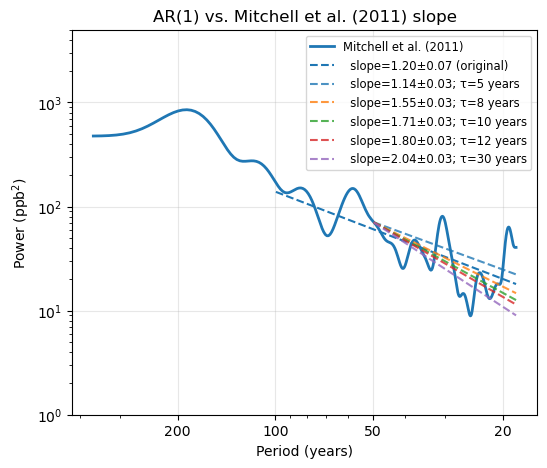

In [129]:
# plot original psd with fit along with AR(1) slopes
fig, ax = plt.subplots(figsize=(6, 5))

# Plot the original data first
ax.loglog(
    1 / frequencies,
    power_original_smooth,
    label="Mitchell et al. (2011)",
    color="tab:blue",
    linewidth=2,
)
ax.plot(
    x_fit_original,
    y_fit_original,
    linestyle="--",
    color="tab:blue",
    label=f"  slope={slope_original:.2f}±{se_slope_original:.2f} (original)",
)

# Choose a reference point to align AR(1) lines with Mitchell data
ref_period = 50  # A good reference point in your period range
ref_idx = np.argmin(np.abs(periods - ref_period))  # Find closest index
mitchell_ref_power = power_original_smooth[ref_idx]  # Power at reference point

# Plot AR(1) fit lines aligned with Mitchell data
for res in results:
    # Find the power that would be predicted by the AR(1) model at the reference period
    ref_power_ar1 = np.exp(res.slope * np.log(ref_period) + res.intercept)

    # Calculate scaling factor to match Mitchell data at reference point
    scale_factor = mitchell_ref_power / ref_power_ar1

    # Apply scaling to the whole fit line (preserves slope, adjusts intercept)
    shifted_y_fit = res.y_fit * scale_factor

    # Plot the shifted fit line
    ax.plot(
        res.x_fit,
        shifted_y_fit,
        linestyle="--",
        alpha=0.8,
        label=f"  slope={res.slope:.2f}±{res.se_slope:.2f}; τ={res.tau} years",
    )

# Custom ticks (guard against out-of-range)
tick_periods = [p for p in [500, 200, 100, 50, 20] if p <= res.period.max()]
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)
ax.set_ylim([1, 5e3])
ax.invert_xaxis()
ax.grid(alpha=0.3)
# Combine the labels neatly
ax.legend(loc="best", fontsize="small")

# Labels, grid, legend
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$)")
ax.set_title("AR(1) vs. Mitchell et al. (2011) slope")